# EFHM quickstart — a 1-in-100-year flood-depth map

This notebook downloads the JRC European Flood Hazard Map for a small area of the
Rhine delta (Netherlands) at the 100-year return period, reading only the AOI's
pixel window over `/vsicurl` — so it transfers kilobytes, not gigabytes. The
EFHM is **CC-BY-4.0** (no licence warning).

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

from earthlens.core import EarthLens

out = Path(tempfile.mkdtemp(prefix="efhm-"))
paths = EarthLens(
    data_source="jrc-flood",
    lat_lim=[51.7, 52.0],
    lon_lim=[4.6, 5.1],
    return_periods=[100],
    path=out,
).download()
paths

2026-08-09 22:00:51 | INFO | pyramids.base.config | Logging is configured.


2026-08-09 22:00:54.070 | INFO     | earthlens.jrc_flood.backend:_fetch_one:330 - JRCFlood RP100: reading window 601x361 px at (34970, 22960) from https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-EFAS/flood_hazard/Europe_RP100_filled_depth.tif


[WindowsPath('C:/Users/main/AppData/Local/Temp/efhm-j6pbiwlh/efhm_RP100.tif')]

## Map the water depth

Cells carry river-flood water depth in metres; -9999 marks no data (dry / outside the modelled river network).

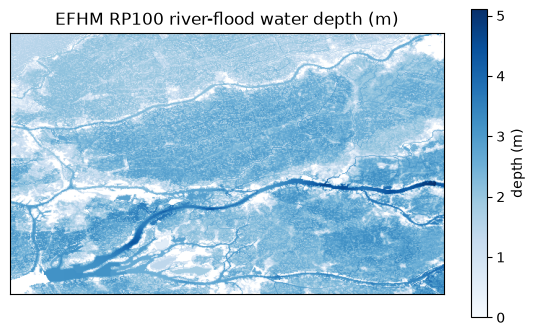

flooded cells: 204,126; max depth: 5.10 m


In [2]:
depth = Dataset.read_file(str(paths[0])).read_array().astype("float64")
depth[depth <= -9999] = np.nan

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(depth, cmap="Blues", vmin=0)
ax.set_title("EFHM RP100 river-flood water depth (m)")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.8, label="depth (m)")
plt.show()
print(
    f"flooded cells: {np.isfinite(depth).sum():,}; max depth: {np.nanmax(depth):.2f} m"
)

## Global vs European coverage

This is the higher-fidelity, Europe-focused EFHM. For the **global** JRC flood
hazard (which also covers Europe, at ~90 m), use the `gee` backend with
`asset="JRC/CEMS_GLOFAS/FloodHazard/v2_1"`.